In [1]:
import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[2])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)
from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import L1WaveletRecon, TotalVariationRecon


## My files
import save_data_helpers
import recon_functions
import recon_plot_helpers
from gating_functions import golden_angle_coords_3d
import sigpy.plot as pl

### Load gated data

In [2]:
idx, resp_trimmed, data_bins, spoke_bins, index_bins = save_data_helpers.load_gate_outputs_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/gates_dense_amp_512.pkl')
print(f'data_bins[0].shape = {data_bins[0].shape}')
print(f'spoke_bins[0].shape = {spoke_bins[0].shape}')

ksp_gate0 = data_bins[0]
coords_gate0 = spoke_bins[0]
ncoils, npts, nsamples = data_bins[0].shape
img_shape = (58, nsamples, nsamples)
print(f'img_shape = {img_shape}')

espirit_mps_gate0 = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/coils/subject2_mid0082/espirit_mps_full_res_ksp_512_ungated.pkl')
print(f'espirit_mps_gate0.shape = {espirit_mps_gate0.shape}')

dcf_ksp_5gates = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/recons/subject2_mid0082/pkl_files_512/dcf_ksp_dense_512_5gates.pkl')
dcf_ksp_gate0 = dcf_ksp_5gates[0]
print(f'dcf_ksp_gate0.shape = {dcf_ksp_gate0.shape}')

ksp_gate0_with_dcf = ksp_gate0 * dcf_ksp_gate0[None,...]
print(f'ksp_gate0_with_dcf.shape = {ksp_gate0_with_dcf.shape}')

Loaded /home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/gates_dense_amp_512.pkl
  idx shape: (113116,)
  signal_trimmed shape: (113116,)
  data_bins: 5 elements
  spoke_bins: 5 elements
  index_bins: 5 elements
data_bins[0].shape = (15, 22623, 512)
spoke_bins[0].shape = (22623, 512, 3)
img_shape = (58, 512, 512)
espirit_mps_gate0.shape = (15, 58, 512, 512)
dcf_ksp_gate0.shape = (22623, 512)
ksp_gate0_with_dcf.shape = (15, 22623, 512)


In [3]:
coils_select = [1, 8, 9, 10, 13]
ksp_coil_select = [ksp_gate0_with_dcf[i] for i in coils_select]
ksp_coil_select = np.stack(ksp_coil_select, axis=0)
print(f'ksp_coil_select.shape = {ksp_coil_select.shape}')


mps_coil_select = [espirit_mps_gate0[i] for i in coils_select]
mps_coil_select = np.stack(mps_coil_select, axis=0)
print(f'mps_coil_select.shape = {mps_coil_select.shape}')

ksp_coil_select.shape = (5, 22623, 512)
mps_coil_select.shape = (5, 58, 512, 512)


### Sigpy TV implentation

In [4]:
max_iter = 5
alpha = 1
lam = 1e-2
device=0


img = TotalVariationRecon(ksp_coil_select, mps_coil_select,
                          lamda=lam, coord=coords_gate0, device=device,
                          max_iter=10).run()

MaxEig:   0%|          | 0/30 [00:00<?, ?it/s]

TotalVariationRecon:   0%|          | 0/10 [00:00<?, ?it/s]

In [5]:
img.dtype

dtype('complex128')

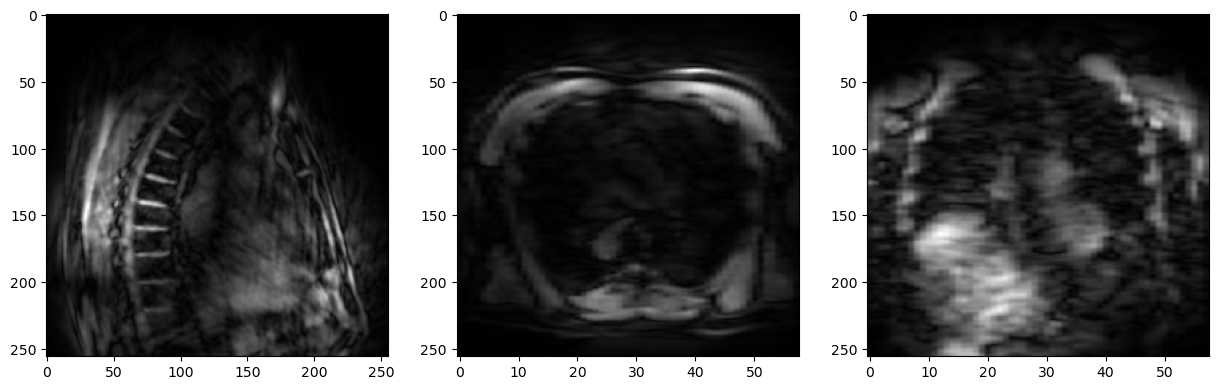

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [6]:
img_cropped = recon_plot_helpers.crop_xy_dimension(img, oshape=(58, 256, 256))
recon_plot_helpers.plot_recons_all_axes(np.abs(cp.asnumpy(img_cropped)))